# Experimento de 4 Braços: CD-NOTS + MMM Bayesiano

**Investigação da Utilização de Descoberta de Estruturas Causais para Calibração de Modelos Bayesianos em Marketing Mix Modeling**

Rafael Silva Ennes — Universidade Presbiteriana Mackenzie, 2026

---

## Design Experimental

| Braço | Descoberta Causal | Framework | Priors |
|-------|-------------------|-----------|--------|
| 1 | Nenhuma | PyMC-Marketing | Padrão (spend-share) |
| 2 | Nenhuma | Google Meridian | Padrão (spend-share) |
| 3 | CD-NOTS | PyMC-Marketing | Calibrados pelo grafo |
| 4 | CD-NOTS | Google Meridian | Calibrados pelo grafo |

A comparação Braço 1 vs 3 e Braço 2 vs 4 isola o efeito da descoberta causal mantendo o framework constante.

---

## Pipeline

```
Dados sintéticos (ground truth conhecido)
         ↓
[Fase 0] CD-NOTS → Grafo causal (direto / mediado / excluído)
         ↓
[Fase 1] Fitting dos 4 braços (2 baseline + 2 graph-informed)
         ↓
[Fase 2] Avaliação: métricas preditivas, atribuição, estrutura, MCMC
```

---
## Seção 0: Configuração do Ambiente

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# ─── Paths das duas repos ───────────────────────────────────────────────────
PYMC_COMPARISON_ROOT = "/home/ennes/mestrado/pymc_meridian_comparison"
CAUSALMMM_ROOT       = "/home/ennes/mestrado/causalmmm_with_cdnots"
ARQUIVOS_RECENTES    = os.path.join(CAUSALMMM_ROOT, "arquivos_recentes")
RESULTS_DIR          = os.path.join(CAUSALMMM_ROOT, "notebooks", "resultados")

os.makedirs(RESULTS_DIR, exist_ok=True)

for p in [PYMC_COMPARISON_ROOT, CAUSALMMM_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"RESULTS_DIR: {RESULTS_DIR}")
print("Paths configurados.")

RESULTS_DIR: /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados
Paths configurados.


In [2]:
import gc
import pickle
import cloudpickle
import time
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from rich.console import Console
from rich.table import Table

# ─── mmm_param_recovery ─────────────────────────────────────────────────────
from mmm_param_recovery.data_generator.core import generate_mmm_dataset
from mmm_param_recovery.data_generator.presets import get_preset_config
from mmm_param_recovery.benchmarking.data_loader import prepare_dataset_for_modeling
from mmm_param_recovery.benchmarking import model_builder, model_fitter, diagnostics, evaluation

# ─── causalmmm (estrutura causal) ────────────────────────────────────────────
# ─── avaliação de estrutura causal (standalone, sem TensorFlow) ───────────────
from importlib.util import spec_from_file_location, module_from_spec as _mfs
_eval_spec = spec_from_file_location(
    "causal_evaluation", os.path.join(ARQUIVOS_RECENTES, "causal_evaluation.py"))
_eval_mod = _mfs(_eval_spec)
_eval_spec.loader.exec_module(_eval_mod)
evaluate_causal_structure = _eval_mod.evaluate_causal_structure

console = Console()
console.print("[green]Imports principais OK[/green]")

# ─── Módulos CD-NOTS (com fallback via importlib) ────────────────────────────
def _load_cdnots_module(name: str, filepath: str):
    """Carrega módulo CD-NOTS registrando no namespace do pacote benchmarking.
    Necessário pois os módulos usam imports relativos (from . import model_builder).
    """
    full_name = f"mmm_param_recovery.benchmarking.{name}"
    spec = importlib.util.spec_from_file_location(full_name, filepath)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[full_name] = mod
    spec.loader.exec_module(mod)
    return mod

try:
    # Tenta importar do pacote (se os arquivos já foram copiados para benchmarking/)
    from mmm_param_recovery.benchmarking import cdnots_discovery, cdnots_model_builder, cdnots_fitter
    console.print("[green]CD-NOTS: módulos carregados do pacote benchmarking[/green]")
except ImportError:
    # Fallback: carrega via importlib em ordem de dependência
    cdnots_discovery     = _load_cdnots_module("cdnots_discovery",
                               os.path.join(ARQUIVOS_RECENTES, "cdnots_discovery.py"))
    cdnots_model_builder = _load_cdnots_module("cdnots_model_builder",
                               os.path.join(ARQUIVOS_RECENTES, "cdnots_model_builder.py"))
    cdnots_fitter        = _load_cdnots_module("cdnots_fitter",
                               os.path.join(ARQUIVOS_RECENTES, "cdnots_fitter.py"))
    console.print("[yellow]CD-NOTS: módulos carregados via importlib (fallback)[/yellow]")

# ─── Meridian: disponibilidade condicional ───────────────────────────────────
try:
    from meridian.model import model as meridian_model_lib  # noqa
    MERIDIAN_AVAILABLE = True
    console.print("[green]Meridian: disponível[/green]")
except ImportError:
    MERIDIAN_AVAILABLE = False
    console.print("[yellow]Meridian: não disponível — braços 2 e 4 serão pulados[/yellow]")

2026-04-12 16:45:35.675609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Imports principais OK

CD-NOTS: módulos carregados via importlib (fallback)

Meridian: disponível

---
## Seção 1: Geração dos Dados Sintéticos

Utilizamos o preset **`small_business`** do framework `mmm_param_recovery`:
- 1 geo ("Local")
- 4 canais de marketing
- 2 variáveis de controle
- 104 semanas (~2 anos)

O dataset tem **ground truth conhecido**: parâmetros de adstock, saturação, contribuições verdadeiras por canal e ROAS verdadeiro.

In [3]:
SEED        = 20250715
PRESET_NAME = "small_business"

config         = get_preset_config(PRESET_NAME, seed=SEED)
dataset_result = generate_mmm_dataset(config)

data_df, channel_columns, control_columns, truth_df = prepare_dataset_for_modeling(
    dataset_result, console=console
)

# Update RESULTS_DIR to include preset subfolder
RESULTS_DIR = os.path.join(CAUSALMMM_ROOT, "notebooks", "resultados", PRESET_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
console.print(f"RESULTS_DIR atualizado: {RESULTS_DIR}")

console.print(f"\nCanais: {channel_columns}")
console.print(f"Controles: {control_columns}")
console.print(f"Shape data_df: {data_df.shape}")
console.print(f"Shape truth_df: {truth_df.shape}")
data_df.head()


 Dataset shape             104 rows × 12 columns                                             
  Effective modeling size   104 rows × 9 columns (time, geo, 4 channels, 2 controls, target)  
  Regions                   ['Local']                                                         
  Date range                2020-01-05 00:00:00 to 2021-12-26 00:00:00                        
  Channels                  4 channels: x1_Search-Ads, x2_Social-Media, x3_Local-Ads...       
  Controls                  2 controls

RESULTS_DIR atualizado: /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados/small_business

Canais: ['x1_Search-Ads', 'x2_Social-Media', 'x3_Local-Ads', 'x4_Email']

Controles: ['c1', 'c2']

Shape data_df: (104, 12)

Shape truth_df: (104, 6)

,time,geo,x1_Search-Ads,x2_Social-Media,x3_Local-Ads,x4_Email,c1,c1_effect,c2,c2_effect,y,population
0,2020-01-05,Local,0.000000,0.000000,0.000000,16.907308,0.0,0.0,0.0,0.0,5797.788136,1
1,2020-01-12,Local,7.352296,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,4892.622850,1
2,2020-01-19,Local,0.000000,0.000000,0.000000,51.680973,0.0,0.0,0.0,0.0,7331.981342,1
3,2020-01-26,Local,0.000000,5.696972,410.120155,0.000000,0.0,0.0,0.0,0.0,7199.239977,1
4,2020-02-02,Local,0.000000,0.000000,425.097649,0.000000,0.0,0.0,0.0,0.0,7477.790998,1


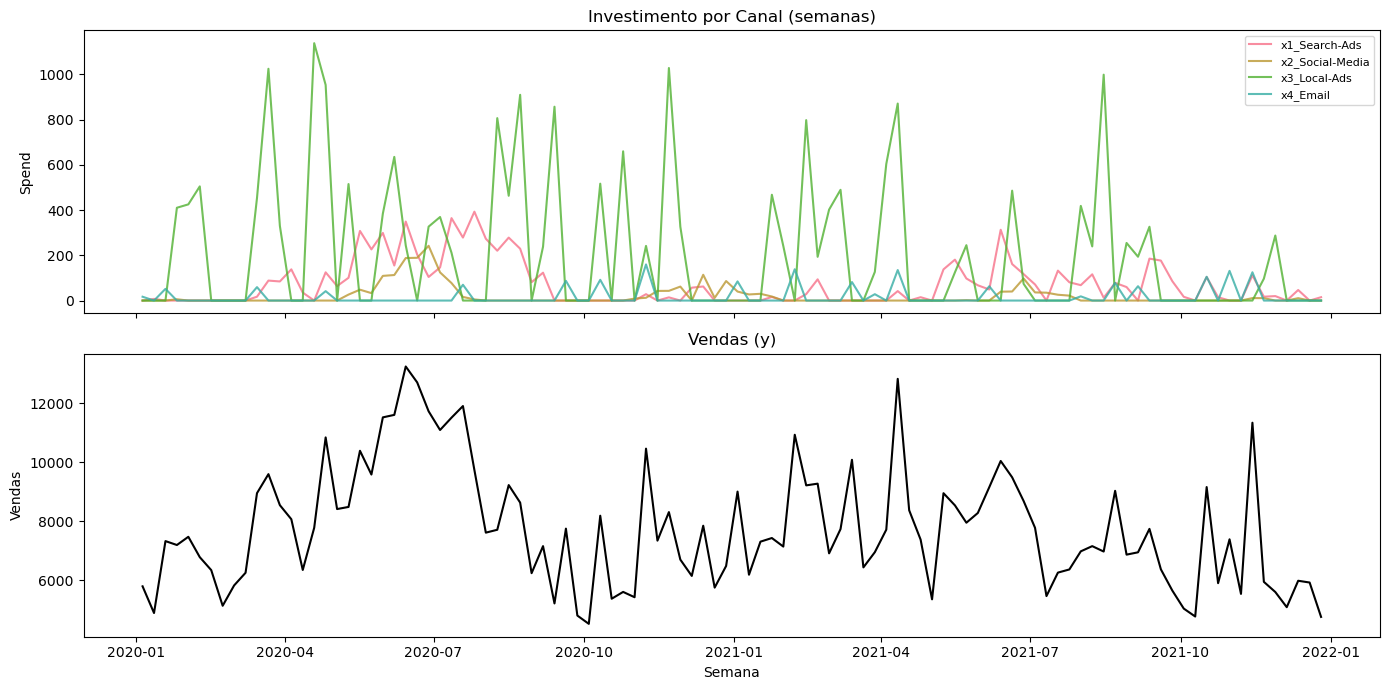

In [4]:
# Visualização dos gastos e vendas ao longo do tempo
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].set_title("Investimento por Canal (semanas)")
for ch in channel_columns:
    axes[0].plot(data_df["time"], data_df[ch], label=ch, alpha=0.8)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("Spend")

axes[1].set_title("Vendas (y)")
axes[1].plot(data_df["time"], data_df["y"], color="black", linewidth=1.5)
axes[1].set_ylabel("Vendas")
axes[1].set_xlabel("Semana")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dados_sinteticos.png"), dpi=150)
plt.show()

---
## Seção 2: Grafo Causal Verdadeiro (Ground Truth)

O gerador `mmm_param_recovery` cria cada canal com efeito **direto** em y via adstock + saturação (Hill function). Não há relações canal → canal no processo gerador. Portanto:

- Todos os `n_channels` canais são **diretos** (aresta canal_i → y)
- Nenhum canal mediado ou excluído no ground truth

Esta estrutura serve como referência para avaliar SHD, Precision, Recall e F1 do CD-NOTS.

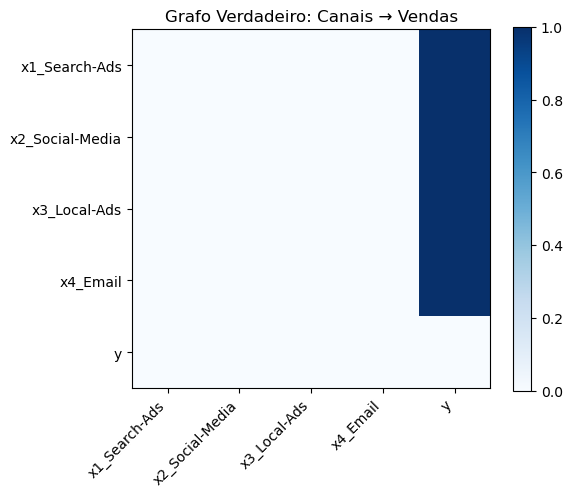

Arestas verdadeiras: 4 (todos os canais → y)

In [5]:
n_channels = len(channel_columns)
n_vars     = n_channels + 1   # canais + y
y_idx      = n_vars - 1

# Matriz de adjacência verdadeira: canal_i → y (índice n_vars-1)
true_adj = np.zeros((n_vars, n_vars))
for i in range(n_channels):
    true_adj[i, y_idx] = 1.0

var_labels = channel_columns + ["y"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(true_adj, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(var_labels, rotation=45, ha="right")
ax.set_yticklabels(var_labels)
ax.set_title("Grafo Verdadeiro: Canais → Vendas")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "grafo_verdadeiro.png"), dpi=150)
plt.show()

console.print(f"Arestas verdadeiras: {int(true_adj.sum())} (todos os canais → y)")

---
## Seção 3: Fase 0 — Descoberta Causal via CD-NOTS

**CD-NOTS** (Constraint-based Causal Discovery from Non-stationary Time Series):

1. Aumenta os dados com variáveis defasadas (t-1, ..., t-lag) e um nó temporal (tendência linear 0→1)
2. Aplica o algoritmo PC com testes de independência condicional:
   - **KCI** (kernel-based, não-linear) se houver **1 geo** — captura efeitos de saturação/adstock
   - **parcorr / Fisher-Z** (linear) se houver **múltiplos geos** — 100–1000× mais rápido; redundância entre geos compensa a linearidade
   - Selecionável via `ci_test="auto"` (padrão), `"kci"` ou `"parcorr"`
3. Para multi-geo: constrói grafo de **consenso por votação majoritária** entre geos (≥ 50% de concordância)
4. Classifica canais como:
   - **Direto** — aresta canal → y no grafo contemporâneo ou defasado
   - **Mediado** — caminho indireto via outro canal
   - **Excluído** — sem caminho para y
   - **Endógeno** — canal confundido por variável de controle (controle → canal AND controle → y)


In [6]:
console.rule("[bold magenta]CD-NOTS: Descoberta Causal[/bold magenta]")

# Nota: data_df tem índice inteiro (geo como coluna), não MultiIndex.
# cdnots_discovery usa path 'national' (todos os dados = 1 geo) — correto para causal_large.
# Para datasets multi-geo, usar: data_df.set_index(["time", "geo"]) antes de chamar.

causal_graph = cdnots_discovery.discover_graph(
    data_df,
    channel_columns,
    control_columns=control_columns,   # ativa detecção controle → mídia (endogeneidade)
    alpha=0.05,
    max_lag=2,
    console=console,
)

# Salvar para reprodutibilidade
graph_path = os.path.join(RESULTS_DIR, "cdnots_graph.pkl")
with open(graph_path, "wb") as f:
    pickle.dump(causal_graph, f)
console.print(f"\n[green]Grafo salvo em:[/green] {graph_path}")

─────────────────────────────────────────── CD-NOTS: Descoberta Causal ────────────────────────────────────────────

CD-NOTS Discovery v2: 4 channels + 2 controls + y = 7 vars, 1/1 geos, 104 timepoints, CI: kci, alpha: 0.05, 
max_lag: 2

         CD-NOTS Discovery Results (v2)          
┏━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Channel         ┃ → y ┃ Category ┃ Endogenous ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━┩
│ x1_Search-Ads   │ ✗   │ mediated │            │
│ x2_Social-Media │ ✓   │ direct   │            │
│ x3_Local-Ads    │ ✗   │ excluded │            │
│ x4_Email        │ ✓   │ direct   │            │
└─────────────────┴─────┴──────────┴────────────┘

Edges: 4 | Direct: 2 | Mediated: 1 | Excluded: 1 | Endogenous: 0 | Runtime: 0.2s

Grafo salvo em: /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados/small_business/cdnots_graph.pkl

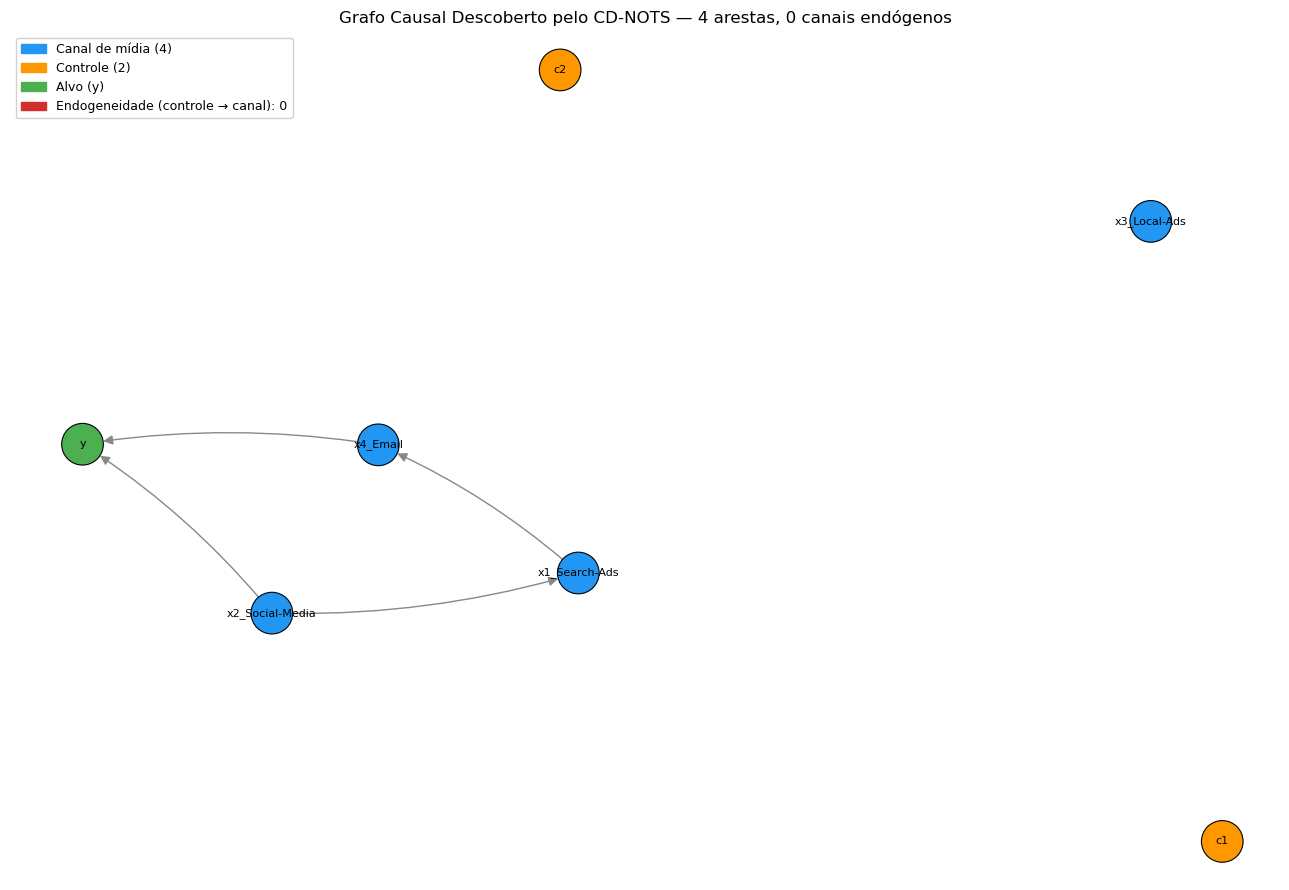

Plot salvo em: /home/ennes/mestrado/causalmmm_with_cdnots/notebooks/resultados/small_business/cdnots_graph.png

Nenhuma aresta controle → canal detectada no grafo de consenso.

In [7]:
# ─── Visualização do grafo causal descoberto (networkx) ──────────────────────
import networkx as nx
from matplotlib.patches import Patch

var_names   = list(causal_graph.variable_names)
adj         = causal_graph.adjacency_matrix
channel_set = set(channel_columns)
control_set = set(control_columns)

def _node_color(name):
    if name in channel_set:
        return "#2196F3"   # canais de mídia
    if name in control_set:
        return "#FF9800"   # controles
    return "#4CAF50"       # alvo y

G = nx.DiGraph()
G.add_nodes_from(var_names)
for i, src in enumerate(var_names):
    for j, dst in enumerate(var_names):
        if adj[i, j] > 0:
            G.add_edge(src, dst)

endog_edges = set(causal_graph.control_to_channel_edges)

node_colors = [_node_color(n) for n in G.nodes()]
edge_colors = ["#D32F2F" if (u, v) in endog_edges else "#888888" for u, v in G.edges()]
edge_styles = ["dashed"  if (u, v) in endog_edges else "solid"   for u, v in G.edges()]
edge_widths = [2.0       if (u, v) in endog_edges else 1.0       for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(13, 9))
pos = nx.spring_layout(G, seed=SEED, k=1.3, iterations=100)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900,
                       edgecolors="black", linewidths=0.8, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
for (u, v), color, style, width in zip(G.edges(), edge_colors, edge_styles, edge_widths):
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        edge_color=color, style=style, width=width,
        arrows=True, arrowsize=14, arrowstyle="-|>",
        connectionstyle="arc3,rad=0.08",
        node_size=900, ax=ax,
    )

legend_handles = [
    Patch(color="#2196F3", label=f"Canal de mídia ({len(channel_set)})"),
    Patch(color="#FF9800", label=f"Controle ({len(control_set)})"),
    Patch(color="#4CAF50", label="Alvo (y)"),
    Patch(color="#D32F2F", label=f"Endogeneidade (controle → canal): {len(endog_edges)}"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)
ax.set_title(
    f"Grafo Causal Descoberto pelo CD-NOTS — {causal_graph.n_edges} arestas, "
    f"{len(causal_graph.endogenous_channels)} canais endógenos"
)
ax.axis("off")
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "cdnots_graph.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
console.print(f"[green]Plot salvo em:[/green] {plot_path}")

if causal_graph.control_to_channel_edges:
    console.print("\n[bold red]Arestas controle → canal detectadas:[/bold red]")
    for ctrl, ch in causal_graph.control_to_channel_edges:
        console.print(f"  {ctrl} → {ch}")
else:
    console.print("\n[dim]Nenhuma aresta controle → canal detectada no grafo de consenso.[/dim]")


  CD-NOTS vs. Grafo  
Verdadeiro — Métricas
     Estruturais     
┏━━━━━━━━━━━┳━━━━━━━┓
┃ Métrica   ┃ Valor ┃
┡━━━━━━━━━━━╇━━━━━━━┩
│ precision │ 0.5   │
│ recall    │ 0.5   │
│ f1        │ 0.5   │
│ fdr       │ 0.5   │
│ shd       │ 4     │
│ tp        │ 2     │
│ fp        │ 2     │
│ fn        │ 2     │
│ tn        │ 14    │
└───────────┴───────┘

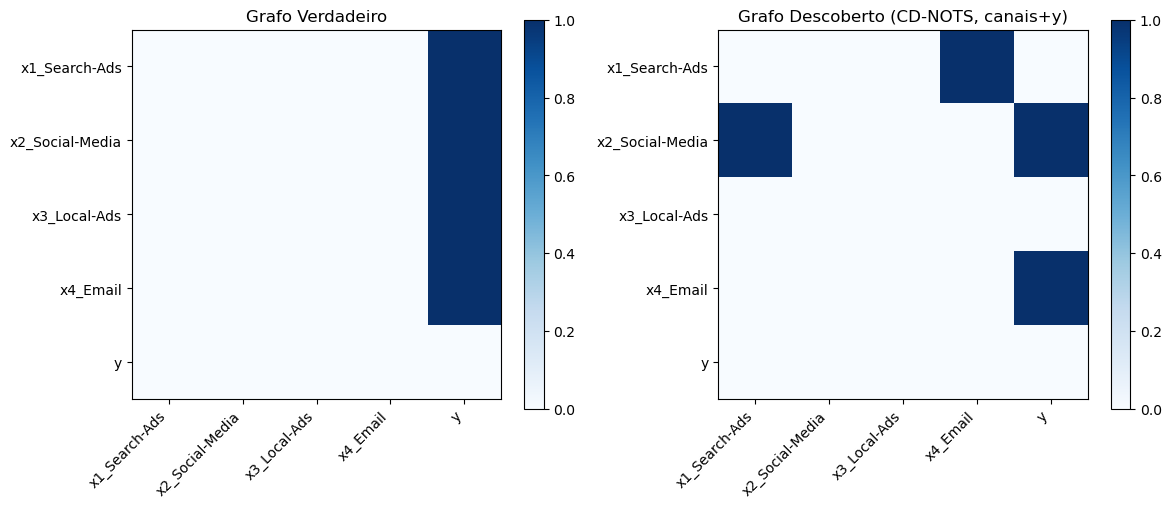

Canais diretos:   ['x2_Social-Media', 'x4_Email']

Canais mediados:  ['x1_Search-Ads']

Canais excluídos: ['x3_Local-Ads']

Runtime CD-NOTS:  0.2s

In [8]:
# ─── Avaliação estrutural: descoberto vs. verdadeiro ─────────────────────────
# O grafo descoberto inclui canais+controles+y; true_adj inclui apenas canais+y.
# Recortamos o subgrafo canais+y no descoberto para alinhar shapes (21x21).
var_names   = list(causal_graph.variable_names)
keep_idx    = [var_names.index(c) for c in channel_columns] + [var_names.index("y")]
learned_sub = causal_graph.adjacency_matrix[np.ix_(keep_idx, keep_idx)]

struct_metrics = evaluate_causal_structure(
    learned_graph=learned_sub,
    true_graph=true_adj,
)

table = Table(title="CD-NOTS vs. Grafo Verdadeiro — Métricas Estruturais")
table.add_column("Métrica", style="cyan")
table.add_column("Valor", style="green")
for k, v in struct_metrics.items():
    table.add_row(k, str(round(v, 4) if isinstance(v, float) else v))
console.print(table)

# Salvar métricas estruturais
pd.DataFrame([struct_metrics]).to_csv(
    os.path.join(RESULTS_DIR, "metricas_estruturais_cdnots.csv"), index=False
)

# ─── Visualização: heatmaps lado a lado ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, adj, title in zip(
    axes,
    [true_adj, learned_sub],
    ["Grafo Verdadeiro", "Grafo Descoberto (CD-NOTS, canais+y)"],
):
    im = ax.imshow(adj, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n_vars))
    ax.set_yticks(range(n_vars))
    ax.set_xticklabels(var_labels, rotation=45, ha="right")
    ax.set_yticklabels(var_labels)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "grafos_comparacao.png"), dpi=150)
plt.show()

console.print(f"Canais diretos:   {list(causal_graph.direct_channels)}")
console.print(f"Canais mediados:  {list(causal_graph.mediated_channels)}")
console.print(f"Canais excluídos: {list(causal_graph.excluded_channels)}")
console.print(f"Runtime CD-NOTS:  {causal_graph.runtime_seconds:.1f}s")

In [9]:
print("ci_test_used:", causal_graph.ci_test_used)
print("n_edges:",      causal_graph.n_edges)
print("runtime:",      causal_graph.runtime_seconds)
print("\nArestas canal→y detectadas:")
y_idx = causal_graph.variable_names.index("y")
for ch in channel_columns:
    ci = causal_graph.variable_names.index(ch)
    has = causal_graph.adjacency_matrix[ci, y_idx] > 0
    print(f"  {ch:30s} {'✓' if has else '✗'}")

ci_test_used: kci
n_edges: 4
runtime: 0.23110748900217004

Arestas canal→y detectadas:
  x1_Search-Ads                  ✗
  x2_Social-Media                ✓
  x3_Local-Ads                   ✗
  x4_Email                       ✓


---
## Seção 4: Configuração do Experimento MCMC

Hiperparâmetros reduzidos para execução interativa no notebook.
Para o benchmark completo, usar: `N_CHAINS=4, N_DRAWS=1000, N_TUNE=1000`.

In [10]:
# ─── Hiperparâmetros MCMC ─────────────────────────────────────────────────────
N_CHAINS      = 2
N_DRAWS       = 500
N_TUNE        = 500
TARGET_ACCEPT = 0.9
SAMPLER       = "nutpie"   # alternativas: "pymc", "blackjax", "numpyro"

CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Dicionário central de resultados: {arm_name: (model, runtime_s, ess_dict) | None}
results: dict = {}

console.print(f"Configuração: {N_CHAINS} chains × {N_DRAWS} draws, tune={N_TUNE}, sampler={SAMPLER}")
console.print(f"Checkpoints em: {CHECKPOINT_DIR}")


Configuração: 2 chains × 500 draws, tune=500, sampler=nutpie

---
## Seção 5: Braço 1 — PyMC-Marketing Baseline

Priors padrão baseados em spend-share. Sem informação causal.

In [11]:
console.rule("[bold cyan]Braço 1: PyMC-Marketing Baseline[/bold cyan]")

_ckpt = os.path.join(CHECKPOINT_DIR, "arm1_pymc_baseline.pkl")
if os.path.exists(_ckpt):
    with open(_ckpt, "rb") as f:
        pymc_baseline, rt_b1, ess_b1 = pickle.load(f)
    console.print(f"[yellow]✓ Checkpoint carregado: {_ckpt}[/yellow]")
else:
    pymc_baseline, rt_b1, ess_b1 = model_fitter.fit_pymc(
        data_df=data_df,
        channel_columns=channel_columns,
        control_columns=control_columns,
        sampler=SAMPLER,
        n_chains=N_CHAINS,
        n_draws=N_DRAWS,
        n_tune=N_TUNE,
        target_accept=TARGET_ACCEPT,
        seed=SEED,
        console=console,
    )
    with open(_ckpt, "wb") as f:
        cloudpickle.dump((pymc_baseline, rt_b1, ess_b1), f)
    console.print(f"[green]✓ Checkpoint salvo: {_ckpt}[/green]")

results["Braço 1: PyMC Baseline"] = (pymc_baseline, rt_b1, ess_b1)
console.print(f"\n[green]✓[/green] Runtime: {rt_b1:.1f}s | ESS mín: {ess_b1.get('min', 'N/A'):.0f}")


──────────────────────────────────────── Braço 1: PyMC-Marketing Baseline ─────────────────────────────────────────

Fitting PyMC-Marketing with nutpie, 2 chains, 500 draws, 500 tune steps

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,1,0.15,31
,1000,0,0.15,63


Output()

Sampling: [y]


Output()

✓ PyMC-Marketing - nutpie: 82.7s, ESS min: 158.4521146928597

✓ Runtime: 82.7s | ESS mín: 158

---
## Seção 6: Braço 2 — Meridian Baseline

Priors baseados em spend-share (mesmo critério do Braço 1). Sem informação causal. (Condicional à disponibilidade do pacote.)


In [12]:
if MERIDIAN_AVAILABLE:
    console.rule("[bold cyan]Braço 2: Meridian Baseline[/bold cyan]")

    _ckpt = os.path.join(CHECKPOINT_DIR, "arm2_meridian_baseline.pkl")
    if os.path.exists(_ckpt):
        with open(_ckpt, "rb") as f:
            meridian_baseline, rt_b2, ess_b2 = pickle.load(f)
        console.print(f"[yellow]✓ Checkpoint carregado: {_ckpt}[/yellow]")
    else:
        meridian_baseline, rt_b2, ess_b2 = model_fitter.fit_meridian(
            data_df=data_df,
            channel_columns=channel_columns,
            control_columns=control_columns,
            n_chains=N_CHAINS,
            n_draws=N_DRAWS,
            n_tune=N_TUNE,
            target_accept=TARGET_ACCEPT,
            seed=SEED,
            console=console,
        )
        with open(_ckpt, "wb") as f:
            cloudpickle.dump((meridian_baseline, rt_b2, ess_b2), f)
        console.print(f"[green]✓ Checkpoint salvo: {_ckpt}[/green]")

    results["Braço 2: Meridian Baseline"] = (meridian_baseline, rt_b2, ess_b2)
    console.print(f"\n[green]✓[/green] Runtime: {rt_b2:.1f}s | ESS mín: {ess_b2.get('min', 'N/A'):.0f}")
else:
    console.print("[yellow]Braço 2 pulado: Meridian não disponível[/yellow]")
    results["Braço 2: Meridian Baseline"] = None


─────────────────────────────────────────── Braço 2: Meridian Baseline ────────────────────────────────────────────

Fitting Meridian with 2 chains, 500 draws, 500 tune steps

2026-04-12 16:49:40.064172: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


✓ Meridian: 274.1s, ESS min: 291.45514188637014

✓ Runtime: 274.1s | ESS mín: 291

---
## Seção 7: Braços 3 e 4 — Priors Calibrados pelo Grafo CD-NOTS

O grafo descoberto pelo CD-NOTS é traduzido em ajustes contínuos de prior (**V2 — "humble priors"**):

### Ajuste de σ (amplitude do efeito)

```
σ_ajustado = σ_base × (1 + damping × direction × confidence)

onde:
  confidence = clip(1 − p_value, 0, 1)
  direction  = +1  (canal com caminho causal para y → alarga prior)
               −1  (canal sem caminho → contrai prior)
  damping    = 0.5 (padrão)  →  ajuste máximo de ±50 %
  floor      = 0.5           →  excluídos retêm no mínimo σ × 0.5
```

### Penalidade por Endogeneidade (Data-Driven)

Canais identificados como **endógenos** (onde `controle → canal`, e.g., Preço → Busca) sofrem um encolhimento (*shrinkage*) proporcional à variância explicada pelo controle.

Utilizamos o fator de **Tolerância** ($1 - R^2$):
- Se o controle explica 80% do canal ($R^2=0.8$), o prior é reduzido em 80%.
- Isso força o modelo a atribuir o efeito ao controle, a menos que os dados de venda sejam extremamente fortes em favor do canal.

### Ajuste de adstock (parâmetro Beta `b`)

| Canal | `b` em Beta(1, b) | Interpretação |
|-------|-------------------|---------------|
| Direto (forte, p≈0) | 2.0 | Carry-over mais longo |
| Direto (fraco, p≈0.5) | 2.5 | Intermediário |
| Não-direto (fraco) | 3.0 (base) | Decaimento padrão |
| Não-direto (forte) | 3.5 | Decaimento mais rápido |

> **Filosofia**: o grafo *informa* o prior, não o *dita*. Evidência fraca → ajuste mínimo; modelo pode sempre sobrescrever o prior pelos dados.
> 
> A V1 usava multiplicadores fixos (×0.1 / ×0.8 / ×1.2) que geravam conflito prior–verossimilhança e divergências MCMC (R-hat > 1.8).


                        Ajuste de Priors via CD-NOTS                         
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Canal           ┃ Categoria ┃ σ base (médio) ┃ Multiplicador ┃ σ ajustado ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ x1_Search-Ads   │ mediado   │ 0.9158         │ 1.494×        │ 1.3680     │
│ x2_Social-Media │ direto    │ 0.2417         │ 1.495×        │ 0.3614     │
│ x3_Local-Ads    │ excluído  │ 2.6456         │ 1.000×        │ 2.6456     │
│ x4_Email        │ direto    │ 0.1969         │ 1.500×        │ 0.2954     │
└─────────────────┴───────────┴────────────────┴───────────────┴────────────┘

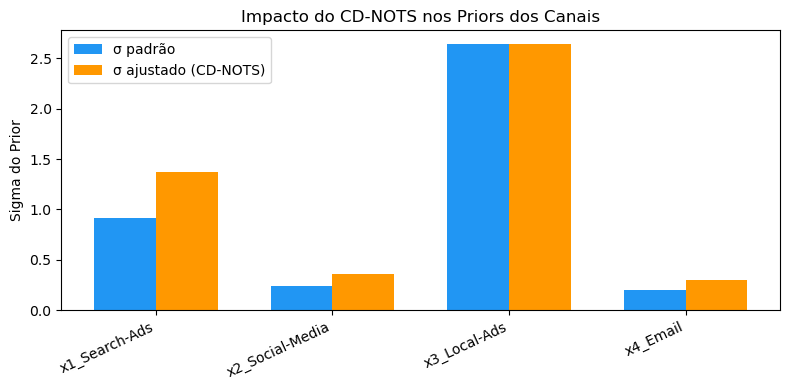

In [13]:
# ─── Visualização do impacto do grafo nos priors ──────────────────────────────
prior_sigma  = model_builder.calculate_prior_sigma(data_df, channel_columns)
multipliers  = cdnots_model_builder._compute_sigma_multipliers(channel_columns, causal_graph)
adj_sigma    = prior_sigma * multipliers[np.newaxis, :]

table = Table(title="Ajuste de Priors via CD-NOTS")
table.add_column("Canal",           style="cyan")
table.add_column("Categoria",       style="magenta")
table.add_column("σ base (médio)",  style="yellow")
table.add_column("Multiplicador",   style="green")
table.add_column("σ ajustado",      style="white")

for i, ch in enumerate(channel_columns):
    cat = (
        "direto"   if ch in causal_graph.direct_channels
        else "mediado"  if ch in causal_graph.mediated_channels
        else "excluído"
    )
    table.add_row(
        ch, cat,
        f"{prior_sigma.mean(axis=0)[i]:.4f}",
        f"{multipliers[i]:.3f}×",
        f"{adj_sigma.mean(axis=0)[i]:.4f}",
    )
console.print(table)

# Gráfico de barras: sigma antes e depois
x = np.arange(n_channels)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, prior_sigma.mean(axis=0), width, label="σ padrão", color="#2196F3")
ax.bar(x + width/2, adj_sigma.mean(axis=0),   width, label="σ ajustado (CD-NOTS)", color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(channel_columns, rotation=25, ha="right")
ax.set_title("Impacto do CD-NOTS nos Priors dos Canais")
ax.set_ylabel("Sigma do Prior")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ajuste_priors.png"), dpi=150)
plt.show()

In [14]:
console.rule("[bold cyan]Braço 3: PyMC-Marketing + CD-NOTS[/bold cyan]")

_ckpt = os.path.join(CHECKPOINT_DIR, "arm3_pymc_cdnots.pkl")
if os.path.exists(_ckpt):
    with open(_ckpt, "rb") as f:
        pymc_cdnots, rt_b3, ess_b3 = pickle.load(f)
    console.print(f"[yellow]✓ Checkpoint carregado: {_ckpt}[/yellow]")
else:
    pymc_cdnots, rt_b3, ess_b3 = cdnots_fitter.fit_pymc_with_graph(
        data_df=data_df,
        channel_columns=channel_columns,
        control_columns=control_columns,
        graph=causal_graph,
        sampler=SAMPLER,
        n_chains=N_CHAINS,
        n_draws=N_DRAWS,
        n_tune=N_TUNE,
        target_accept=TARGET_ACCEPT,
        seed=SEED,
        console=console,
    )
    with open(_ckpt, "wb") as f:
        cloudpickle.dump((pymc_cdnots, rt_b3, ess_b3), f)
    console.print(f"[green]✓ Checkpoint salvo: {_ckpt}[/green]")

results["Braço 3: PyMC + CD-NOTS"] = (pymc_cdnots, rt_b3, ess_b3)
console.print(f"\n[green]✓[/green] Runtime: {rt_b3:.1f}s | ESS mín: {ess_b3.get('min', 'N/A'):.0f}")


──────────────────────────────────────── Braço 3: PyMC-Marketing + CD-NOTS ────────────────────────────────────────

Fitting PyMC-Marketing + CD-NOTS with nutpie, 2 chains, 500 draws, 500 tune steps

Graph: 2 direct, 1 mediated, 1 excluded


  Prior adjustments (damping=0.5, floor=0.4):
                     x1_Search-Ads: σ×1.494 ↑  (p=1.0000, mediated)
                   x2_Social-Media: σ×1.495 ↑  (p=0.0096, direct)
                      x3_Local-Ads: σ×1.000 =  (p=1.0000, excluded)
                          x4_Email: σ×1.500 ↑  (p=0.0000, direct)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,8,0.14,63
,1000,8,0.12,127


Output()

Sampling: [y]


Output()

✓ PyMC + CD-NOTS - nutpie: 89.2s, ESS min: 140.0250792663693

✓ Runtime: 89.2s | ESS mín: 140

In [ ]:
if MERIDIAN_AVAILABLE:
    console.rule("[bold cyan]Braço 4: Meridian + CD-NOTS[/bold cyan]")

    _ckpt = os.path.join(CHECKPOINT_DIR, "arm4_meridian_cdnots.pkl")
    if os.path.exists(_ckpt):
        with open(_ckpt, "rb") as f:
            meridian_cdnots, rt_b4, ess_b4 = pickle.load(f)
        console.print(f"[yellow]✓ Checkpoint carregado: {_ckpt}[/yellow]")
    else:
        meridian_cdnots, rt_b4, ess_b4 = cdnots_fitter.fit_meridian_with_graph(
            data_df=data_df,
            channel_columns=channel_columns,
            control_columns=control_columns,
            graph=causal_graph,
            n_chains=N_CHAINS,
            n_draws=N_DRAWS,
            n_tune=N_TUNE,
            target_accept=TARGET_ACCEPT,
            seed=SEED,
            console=console,
        )
        with open(_ckpt, "wb") as f:
            cloudpickle.dump((meridian_cdnots, rt_b4, ess_b4), f)
        console.print(f"[green]✓ Checkpoint salvo: {_ckpt}[/green]")

    results["Braço 4: Meridian + CD-NOTS"] = (meridian_cdnots, rt_b4, ess_b4)
    console.print(f"\n[green]✓[/green] Runtime: {rt_b4:.1f}s | ESS mín: {ess_b4.get('min', 'N/A'):.0f}")
else:
    console.print("[yellow]Braço 4 pulado: Meridian não disponível[/yellow]")
    results["Braço 4: Meridian + CD-NOTS"] = None


─────────────────────────────────────────── Braço 4: Meridian + CD-NOTS ───────────────────────────────────────────

Fitting Meridian + CD-NOTS with 2 chains, 500 draws, 500 tune steps

Graph: 2 direct, 1 mediated, 1 excluded


  Prior adjustments (damping=0.5, floor=0.4):
                     x1_Search-Ads: σ×1.494 ↑  (p=1.0000, mediated)
                   x2_Social-Media: σ×1.495 ↑  (p=0.0096, direct)
                      x3_Local-Ads: σ×1.000 =  (p=1.0000, excluded)
                          x4_Email: σ×1.500 ↑  (p=0.0000, direct)


---
## Seção 8: Avaliação Comparativa — Métricas de Ajuste

**Métricas preditivas** por braço:
- R² (coeficiente de determinação)
- MAPE % (Mean Absolute Percentage Error)
- sRMSE (scaled Root Mean Squared Error)
- Bias
- Durbin-Watson (autocorrelação dos resíduos)

In [ ]:
all_perf_rows = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        continue
    model_obj, runtime, ess = arm_result

    if "PyMC" in arm_name:
        rows = evaluation.evaluate_pymc_fit(model_obj, data_df, SAMPLER)
    elif "Meridian" in arm_name:
        rows = evaluation.evaluate_meridian_fit(model_obj, data_df)
    else:
        continue

    for r in rows:
        r["Braço"] = arm_name
    all_perf_rows.extend(rows)

perf_df = pd.DataFrame(all_perf_rows)
perf_df.to_csv(os.path.join(RESULTS_DIR, "metricas_ajuste.csv"), index=False)
console.print("[green]Métricas de ajuste salvas.[/green]")
perf_df

---
## Seção 9: Avaliação Comparativa — Contribuição dos Canais

**Métricas de atribuição** (ground truth recovery):
- sRMSE e MAPE das contribuições estimadas vs. verdadeiras por canal
- Correlação entre contribuições estimadas e verdadeiras
- Recovery do ROAS por canal

In [ ]:
all_contrib_rows    = []
all_contrib_summary = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        continue
    model_obj, runtime, ess = arm_result

    try:
        if "PyMC" in arm_name:
            ch_df, avg_metrics = evaluation.evaluate_pymc_channel_contributions(
                model_obj, truth_df, channel_columns, SAMPLER, PRESET_NAME
            )
        elif "Meridian" in arm_name:
            ch_df, avg_metrics = evaluation.evaluate_meridian_channel_contributions(
                model_obj, truth_df, channel_columns, PRESET_NAME
            )
        else:
            continue

        ch_df["Braço"] = arm_name
        all_contrib_rows.append(ch_df)
        all_contrib_summary.append({"Braço": arm_name, **avg_metrics})

    except Exception as e:
        console.print(f"[red]Erro ao avaliar contribuições de {arm_name}: {e}[/red]")

if all_contrib_rows:
    contrib_df = pd.concat(all_contrib_rows, ignore_index=True)
    contrib_df.to_csv(os.path.join(RESULTS_DIR, "contribuicao_canais.csv"), index=False)

contrib_summary_df = pd.DataFrame(all_contrib_summary)
contrib_summary_df.to_csv(os.path.join(RESULTS_DIR, "contribuicao_canais_resumo.csv"), index=False)
console.print("[green]Métricas de contribuição salvas.[/green]")
contrib_summary_df

---
## Seção 10: Diagnósticos de Convergência MCMC

- **ESS** (Effective Sample Size): mínimo e mediana
- **R-hat**: máximo e contagem de variáveis com R-hat > 1.1
- **Divergências**: contagem total

In [ ]:
diag_rows = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        diag_rows.append({"Braço": arm_name, "Status": "N/D"})
        continue
    model_obj, runtime, ess = arm_result

    # Obter inference data
    idata = getattr(model_obj, "idata", None) or getattr(model_obj, "inference_data", None)

    if idata is not None:
        try:
            divergencias = diagnostics.compute_divergences(idata)
            rhat         = diagnostics.compute_rhat(idata)
        except Exception:
            divergencias = None
            rhat = {"max": None, "bad_count": None}
    else:
        divergencias = None
        rhat = {"max": None, "bad_count": None}

    diag_rows.append({
        "Braço":        arm_name,
        "ESS mín":      round(ess.get("min",  np.nan), 0) if ess else None,
        "ESS q50":      round(ess.get("q50",  np.nan), 0) if ess else None,
        "R-hat máx":    round(rhat["max"],       4) if rhat["max"]       is not None else None,
        "R-hat > 1.1":  rhat["bad_count"]                if rhat["bad_count"]  is not None else None,
        "Divergências": divergencias,
        "Runtime (s)":  round(runtime, 1),
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(os.path.join(RESULTS_DIR, "diagnosticos_mcmc.csv"), index=False)
console.print("[green]Diagnósticos salvos.[/green]")
diag_df

---
## Seção 11: Tabela Resumo Final

Consolida todas as dimensões de avaliação em uma única tabela comparativa.

In [ ]:
summary_rows = []

for arm_name, arm_result in results.items():
    if arm_result is None:
        summary_rows.append({"Braço": arm_name, "Status": "N/D"})
        continue
    model_obj, runtime, ess = arm_result

    # Métricas de ajuste (média entre geos)
    try:
        if "PyMC" in arm_name:
            fit_rows = evaluation.evaluate_pymc_fit(model_obj, data_df, SAMPLER)
        else:
            fit_rows = evaluation.evaluate_meridian_fit(model_obj, data_df)
        r2_mean   = np.nanmean([r["R²"]      for r in fit_rows if r.get("R²")      is not None])
        mape_mean = np.nanmean([r["MAPE (%)"] for r in fit_rows if r.get("MAPE (%)") is not None])
    except Exception:
        r2_mean = mape_mean = np.nan

    # Métricas de contribuição
    contrib_row = next((r for r in all_contrib_summary if r["Braço"] == arm_name), {})

    # Métricas estruturais (só para braços CD-NOTS)
    shd = struct_metrics.get("shd", None) if "CD-NOTS" in arm_name else None
    f1  = struct_metrics.get("f1",  None) if "CD-NOTS" in arm_name else None

    summary_rows.append({
        "Braço":             arm_name,
        "R² (fit)": round(r2_mean,  4) if not np.isnan(r2_mean)  else None,
        "MAPE % (fit)": round(mape_mean, 2) if not np.isnan(mape_mean) else None,
        "sRMSE (contrib)": round(contrib_row.get("SRMSE", np.nan), 4) if contrib_row else None,
        "MAPE % (contrib)": round(contrib_row.get("MAPE (%)", np.nan), 2) if contrib_row else None,
        "ESS mín":    round(ess.get("min", np.nan), 0) if ess else None,
        "ESS q50":    round(ess.get("q50", np.nan), 0) if ess else None,
        "SHD grafo":  shd,
        "F1 grafo":   round(f1, 4) if f1 is not None else None,
        "Runtime (s)": round(runtime, 1),
        "CD-NOTS":    "Sim" if "CD-NOTS" in arm_name else "Não",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, "resumo_experimento.csv"), index=False)
console.print("[bold green]Resumo do experimento salvo.[/bold green]")
summary_df

---
## Seção 12: Visualizações Comparativas

In [ ]:
# Filtra apenas braços com resultados
if "Status" in summary_df.columns:
    valid_df = summary_df[summary_df["Status"] != "N/D"].copy()
else:
    valid_df = summary_df.copy()
valid_df = valid_df.dropna(subset=["R² (fit)"])

if len(valid_df) == 0:
    console.print("[yellow]Sem resultados válidos para visualização.[/yellow]")
else:
    modelos = valid_df["Braço"].str.split(": ").str[1].tolist()
    cores   = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"][: len(modelos)]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Comparação dos 4 Braços", fontsize=14, fontweight="bold")

    # R² de ajuste
    axes[0].bar(range(len(modelos)), valid_df["R² (fit)"].fillna(0), color=cores)
    axes[0].set_xticks(range(len(modelos)))
    axes[0].set_xticklabels(modelos, rotation=30, ha="right")
    axes[0].set_title("R² (ajuste ao dados)")
    axes[0].set_ylim(0, 1)
    axes[0].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)

    # MAPE de contribuição
    if "MAPE % (contrib)" in valid_df.columns and valid_df["MAPE % (contrib)"].notna().any():
        axes[1].bar(range(len(modelos)), valid_df["MAPE % (contrib)"].fillna(0), color=cores)
        axes[1].set_xticks(range(len(modelos)))
        axes[1].set_xticklabels(modelos, rotation=30, ha="right")
        axes[1].set_title("MAPE % (contribuição canais)")
        axes[1].set_ylabel("MAPE %")
    else:
        axes[1].text(0.5, 0.5, "N/D", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("MAPE % (contribuição canais)")

    # Runtime
    axes[2].bar(range(len(modelos)), valid_df["Runtime (s)"].fillna(0), color=cores)
    axes[2].set_xticks(range(len(modelos)))
    axes[2].set_xticklabels(modelos, rotation=30, ha="right")
    axes[2].set_title("Runtime (segundos)")
    axes[2].set_ylabel("Segundos")

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "comparacao_4bracos.png"), dpi=150)
    plt.show()


In [ ]:
# ESS Comparison
if len(valid_df) > 0 and "ESS mín" in valid_df.columns and valid_df["ESS mín"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(modelos))
    width = 0.35
    ess_min = valid_df["ESS mín"].fillna(0).values
    ess_q50 = valid_df["ESS q50"].fillna(0).values
    ax.bar(x - width/2, ess_min, width, label="ESS mínimo",  color="#2196F3")
    ax.bar(x + width/2, ess_q50, width, label="ESS mediana", color="#FF9800")
    ax.axhline(y=400, color="red", linestyle="--", alpha=0.7, label="Limiar 400")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=25, ha="right")
    ax.set_title("Effective Sample Size (ESS) por Braço")
    ax.set_ylabel("ESS")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "ess_comparacao.png"), dpi=150)
    plt.show()

---
## Seção 13: Limpeza de Memória

In [ ]:
for key in list(results.keys()):
    arm_result = results.pop(key)
    if arm_result is not None:
        model_obj, _, _ = arm_result
        del model_obj
        del arm_result

gc.collect()
console.print("[green]Memória liberada.[/green]")

---
## Seção 14: Conclusões

### Arquivos gerados

Todos os resultados foram salvos em `notebooks/resultados/<preset_name>/` (subpasta criada automaticamente pelo nome do preset):

| Arquivo | Conteúdo |
|---------|----------|
| `resumo_experimento.csv` | Todas as métricas por braço |
| `metricas_ajuste.csv` | R², MAPE, sRMSE, Bias, DW por geo |
| `contribuicao_canais.csv` | Métricas de atribuição por canal×geo |
| `contribuicao_canais_resumo.csv` | Médias de atribuição por braço |
| `diagnosticos_mcmc.csv` | ESS, R-hat, divergências |
| `metricas_estruturais_cdnots.csv` | SHD, F1, Precision, Recall do grafo |
| `cdnots_graph.pkl` | Objeto CausalGraph para reprodutibilidade |
| `comparacao_4bracos.png` | Gráfico comparativo principal |
| `grafos_comparacao.png` | Heatmaps dos grafos verdadeiro vs. descoberto |
| `ajuste_priors.png` | Impacto do CD-NOTS nos priors |

---

### Análise dos Resultados

> **[PLACEHOLDER]** — Preencher após execução com os resultados reais.

**Descoberta Causal (Seção 3):**
- SHD: `___` | Precision: `___` | Recall: `___` | F1: `___`
- Canais diretos identificados: `___`
- Canais excluídos: `___`

**Ajuste ao dados (R²):**
- Braço 1 (PyMC baseline): `___`
- Braço 2 (Meridian baseline): `___`
- Braço 3 (PyMC + CD-NOTS): `___`
- Braço 4 (Meridian + CD-NOTS): `___`

**Atribuição de canais (MAPE %):**
- Braço 1 vs Braço 3 (PyMC): `___` vs `___` → melhoria de `___%`
- Braço 2 vs Braço 4 (Meridian): `___` vs `___` → melhoria de `___%`

**Convergência MCMC:**
- ESS mínimo satisfatório (> 400) em todos os braços: `[Sim/Não]`
- R-hat < 1.1 em todos os parâmetros: `[Sim/Não]`

---

### Hipóteses Testadas

1. **H1**: CD-NOTS consegue descobrir estruturas causais informativas com 104 observações semanais. → _[a ser validado pelo SHD/F1]_

2. **H2**: A tradução do grafo em priors ajustados melhora a acurácia preditiva e de atribuição. → _[a ser validado comparando Braços 1vs3 e 2vs4]_

3. **H3**: A abordagem é aplicável em contextos com poucos dados geográficos (N < 10 geos). → _[validado pelo preset `small_business` com 1 geo]_